# zamato data analysis using python

# import library

In [1]:
import pandas as pd
import numpy as np
import  matplotlib.pyplot as plt
import seaborn as sns

# 2 create the dataset

In [4]:
df = pd.read_csv("Zomato data .csv")
df

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1/5,775,800,Buffet
1,Spice Elephant,Yes,No,4.1/5,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8/5,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7/5,88,300,Buffet
4,Grand Village,No,No,3.8/5,166,600,Buffet
...,...,...,...,...,...,...,...
143,Melting Melodies,No,No,3.3/5,0,100,Dining
144,New Indraprasta,No,No,3.3/5,0,150,Dining
145,Anna Kuteera,Yes,No,4.0/5,771,450,Dining
146,Darbar,No,No,3.0/5,98,800,Dining


In [5]:
df.head()

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1/5,775,800,Buffet
1,Spice Elephant,Yes,No,4.1/5,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8/5,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7/5,88,300,Buffet
4,Grand Village,No,No,3.8/5,166,600,Buffet


# let's convert the data type of the "rate" column to fload and remove the denominator

In [9]:
def handleRate(value):
    value = str(value).split('/')
    return float(value[0])

df['rate'] = df['rate'].apply(handleRate)
print(df.head())


                    name online_order book_table  rate  votes  \
0                  Jalsa          Yes        Yes   4.1    775   
1         Spice Elephant          Yes         No   4.1    787   
2        San Churro Cafe          Yes         No   3.8    918   
3  Addhuri Udupi Bhojana           No         No   3.7     88   
4          Grand Village           No         No   3.8    166   

   approx_cost(for two people) listed_in(type)  
0                          800          Buffet  
1                          800          Buffet  
2                          800          Buffet  
3                          300          Buffet  
4                          600          Buffet  


In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 148 entries, 0 to 147
Data columns (total 7 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   name                         148 non-null    str    
 1   online_order                 148 non-null    str    
 2   book_table                   148 non-null    str    
 3   rate                         148 non-null    float64
 4   votes                        148 non-null    int64  
 5   approx_cost(for two people)  148 non-null    int64  
 6   listed_in(type)              148 non-null    str    
dtypes: float64(1), int64(2), str(4)
memory usage: 12.0 KB


# conclusion - there is no Null value in df

# Types of Resturant

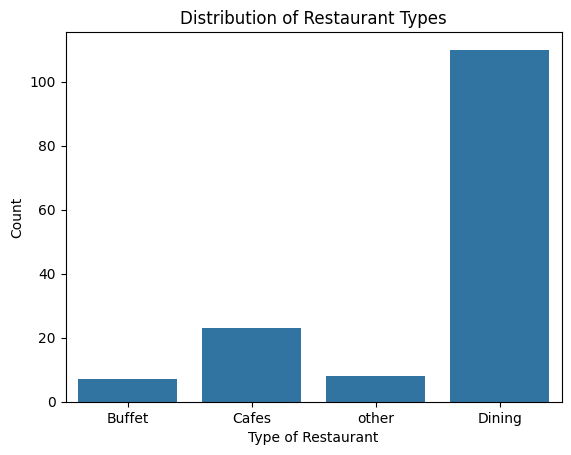

In [12]:

sns.countplot(x='listed_in(type)', data=df)
plt.xlabel("Type of Restaurant")
plt.ylabel("Count")
plt.title("Distribution of Restaurant Types")

plt.show()

# conclusion : the majoriti of the resaurants fall int the diningg category

# dining resaurants are preferred by a larger number of individuals

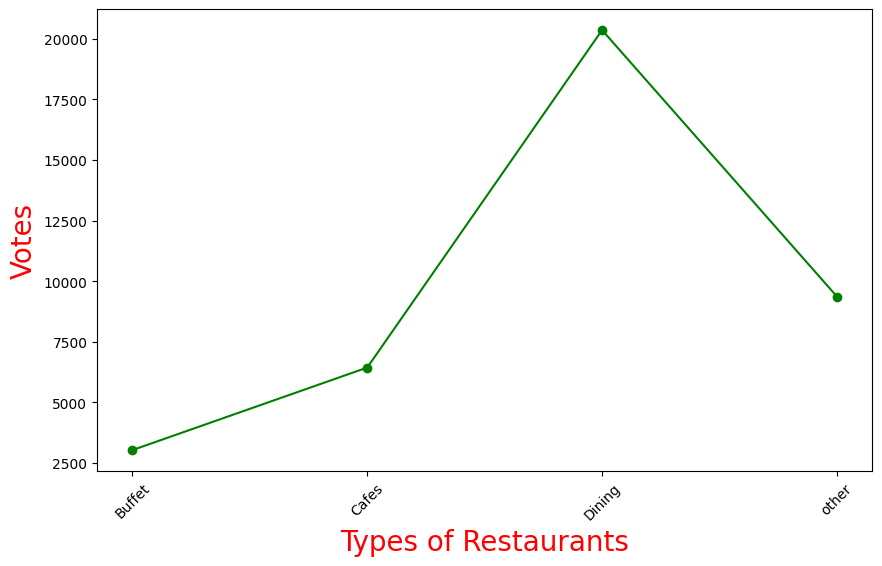

In [15]:
group_data = df.groupby('listed_in(type)')['votes'].sum()

plt.figure(figsize=(10,6))
plt.plot(group_data, color="green", marker='o')

plt.xlabel("Types of Restaurants", color="red", size=20)
plt.ylabel("Votes", color="red", size=20)
plt.xticks(rotation=45)

plt.show()


# the majariti restaurent received retting

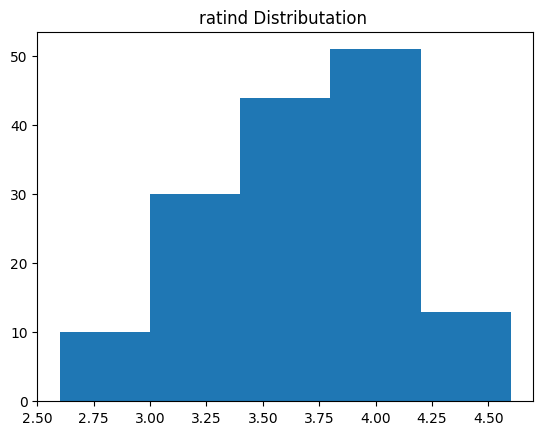

In [19]:
plt.hist(df['rate'],bins = 5)
plt.title("ratind Distributation ")
plt.show()

<Axes: xlabel='approx_cost(for two people)', ylabel='count'>

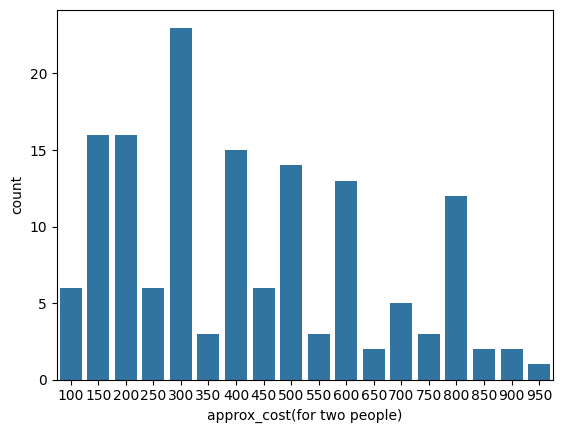

In [20]:
couple_data = df['approx_cost(for two people)']
sns.countplot(x= couple_data)

<Axes: xlabel='online_order', ylabel='rate'>

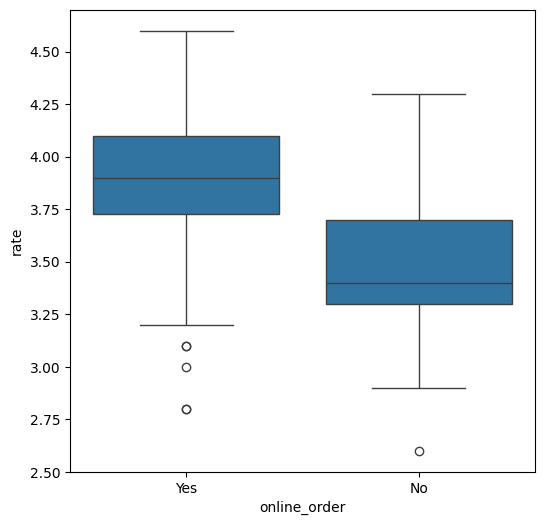

In [21]:
plt.figure(figsize=(6,6))
sns.boxplot(x = 'online_order',y = 'rate',data = df)

In [26]:


pivot_table = df.pivot_table(

    index='listed_in(type)',
    columns='online_order',
    aggfunc='sum'
)

plt.figure(figsize=(10,6))
sns.heatmap(pivot_table, annot=True, cmap="YlGnBu", fmt=".0f")

plt.title("Heatmap")
plt.xlabel("Online Order")
plt.ylabel("Listed In (Type)")

plt.show()


ValueError: could not convert string to float: 'NoNoNo'

<Figure size 1000x600 with 0 Axes>